**Loading Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve , auc, precision_recall_curve, roc_auc_score
)

import random
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")


!pip install mealpy
from mealpy.swarm_based.GWO import OriginalGWO

print("mealpy and OriginalGWO imported successfully!")

mealpy and OriginalGWO imported successfully!


**Uploding datasets**

In [ ]:
train_df = pd.read_csv('/content/train.csv',encoding='latin1')

In [ ]:
test_df =pd.read_csv('/content/test.csv',encoding='latin1')

Seeing Columns Name

In [ ]:
train_df.columns.values

array(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype=object)

In [ ]:
train_df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


Fixing Spelling Errors

In [ ]:
train_df = train_df.rename({'austim':'autism', 'contry_of_res':'country_of_res'}, axis=1)

In [ ]:
test_df = test_df.rename({'austim':'autism', 'contry_of_res':'country_of_res'},axis=1)

In [ ]:
columns_to_drop = ['ID', 'age_desc', 'relation']
existing_columns = [col for col in columns_to_drop if col in train_df.columns]
if existing_columns:
    train_df = train_df.drop(existing_columns, axis=1)
    test_df  = test_df.drop(existing_columns, axis=1)

In [ ]:
train_df = train_df.replace("?", np.nan)

In [ ]:
test_df = test_df.replace("?", np.nan)

In [ ]:
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = train_df.select_dtypes(include=['object']).columns


In [ ]:
train_df_encoded = pd.get_dummies(train_df, drop_first=True)
y = train_df_encoded["Class/ASD"]
X = train_df_encoded.drop("Class/ASD", axis=1)

Imputation

In [ ]:
mean_imputer = SimpleImputer(strategy="mean")

In [ ]:
# Numeric → Mean
mean_imputer = SimpleImputer(strategy='mean')
train_df[num_cols] = mean_imputer.fit_transform(train_df[num_cols])

# Categorical → Mode
mode_imputer = SimpleImputer(strategy='most_frequent')
train_df[cat_cols] = mode_imputer.fit_transform(train_df[cat_cols])


Label Encoding

In [ ]:
le = LabelEncoder()
for col in cat_cols:
    train_df[col] = le.fit_transform(train_df[col])


In [ ]:
train_df_encoded = pd.get_dummies(train_df, drop_first=True)
y = train_df_encoded["Class/ASD"]
X = train_df_encoded.drop("Class/ASD", axis=1)

Exploratory Data Analysis (EDA)

In [ ]:
combo_counts = train_df.groupby(['jaundice', 'autism']).size().reset_index(name='count')
print(combo_counts)


   jaundice  autism  count
0         0       0    528
1         0       1     87
2         1       0    141
3         1       1     44


Ananlyzing Features

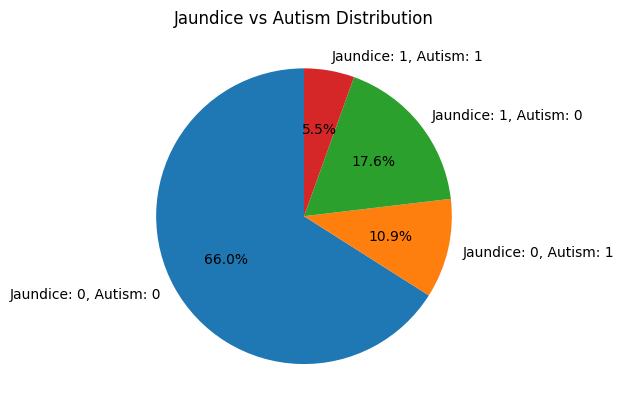

In [ ]:
labels = (
       "Jaundice: " + combo_counts['jaundice'].astype(str) +
       ", Autism: " + combo_counts['autism'].astype(str)
)
plt.pie (combo_counts['count'], labels=labels , autopct='%1.1f%%', startangle=90)
plt.title("Jaundice vs Autism Distribution")
plt.show()

Visualizing Data Sets

In [ ]:
country_counts = train_df['country_of_res'].value_counts()
country_counts[country_counts <= 25].size


48

In [ ]:
over30 = country_counts[country_counts > 30]
over30

,count
country_of_res,
54,134
25,108
36,78
53,67
31,55
52,40
6,37


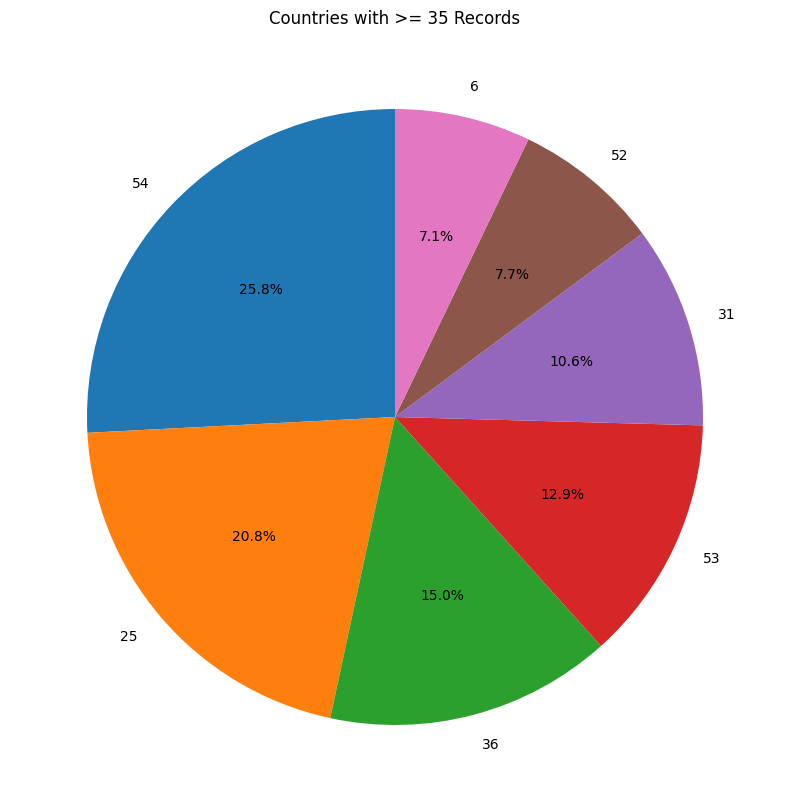

In [ ]:
country_counts = train_df['country_of_res'].value_counts()
small_countries = country_counts[country_counts >= 35]
plt.figure(figsize=(10, 10))
plt.pie(
    small_countries.values,
    labels=small_countries.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Countries with >= 35 Records")
plt.show()

Feature Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
# The error 'ValueError: could not convert string to float: 'f'' indicates that
# X still contains categorical string columns that MinMaxScaler cannot process.
# We re-apply pd.get_dummies to X to ensure all string columns are converted.
X_processed = pd.get_dummies(X, drop_first=True)
X_minmax = minmax.fit_transform(X_processed)

In [ ]:
std = StandardScaler()
# The error 'ValueError: could not convert string to float: 'f'' indicates that
# X still contains categorical string columns that MinMaxScaler cannot process.
# We re-apply pd.get_dummies to X to ensure all string columns are converted.
X_processed_std = pd.get_dummies(X, drop_first=True)
X_std = std.fit_transform(X_processed_std)

In [ ]:
scaler = MinMaxScaler()
# The error 'ValueError: could not convert string to float: 'f'' indicates that
# X still contains categorical string columns that MinMaxScaler cannot process.
# We re-apply pd.get_dummies to X to ensure all string columns are converted.
X_processed_scaled = pd.get_dummies(X, drop_first=True)
X_scaled = scaler.fit_transform(X_processed_scaled)


Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



Feature Selection (Chi-square)

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
chi = SelectKBest(score_func=chi2, k=20)
X_chi = chi.fit_transform(abs(X_scaled), y)


Feature Extraction (PCA)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

In [ ]:
pca.components_.shape

(5, 18)

Grey Wolf Method

In [ ]:
class GreyWolfOptimizer:
    def __init__(self, obj_func, dim, lb, ub, n_agents=10, max_iter=20):
        self.obj_func = obj_func
        self.dim = dim
        self.lb = lb
        self.ub = ub
        self.n_agents = n_agents
        self.max_iter = max_iter

        self.positions = np.random.randint(lb, ub, (n_agents, dim))
        # Initialize alpha, beta, delta as copies of initial positions
        # This assumes the first three positions are initial candidates,
        # their scores will be updated in the optimize loop.
        self.alpha = np.copy(self.positions[0])
        self.beta = np.copy(self.positions[1])
        self.delta = np.copy(self.positions[2])
        self.alpha_score = float('inf')
        self.beta_score = float('inf')
        self.delta_score = float('inf')

    def optimize(self):
        for t in range(self.max_iter):
            a = 2 - t * (2 / self.max_iter) # 'a' decreases linearly from 2 to 0
            for i in range(self.n_agents):
                # Calculate fitness for current position
                current_fitness = self.obj_func(self.positions[i])

                # Update alpha, beta, delta wolves
                if current_fitness < self.alpha_score:
                    self.delta_score = self.beta_score
                    self.delta = np.copy(self.beta)
                    self.beta_score = self.alpha_score
                    self.beta = np.copy(self.alpha)
                    self.alpha_score = current_fitness
                    self.alpha = np.copy(self.positions[i])
                elif current_fitness < self.beta_score:
                    self.delta_score = self.beta_score
                    self.delta = np.copy(self.beta)
                    self.beta_score = current_fitness
                    self.beta = np.copy(self.positions[i])
                elif current_fitness < self.delta_score:
                    self.delta_score = current_fitness
                    self.delta = np.copy(self.positions[i])

                # Update positions of search agents
                r1, r2 = np.random.random(), np.random.random()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = np.abs(C1 * self.alpha - self.positions[i])
                X1 = self.alpha - A1 * D_alpha

                r1, r2 = np.random.random(), np.random.random()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = np.abs(C2 * self.beta - self.positions[i])
                X2 = self.beta - A2 * D_beta

                r1, r2 = np.random.random(), np.random.random()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = np.abs(C3 * self.delta - self.positions[i])
                X3 = self.delta - A3 * D_delta

                new_pos = (X1 + X2 + X3) / 3
                # Ensure positions are within bounds and integer type for K
                self.positions[i] = np.clip(new_pos, self.lb, self.ub).astype(int)
        return self.alpha, self.alpha_score

In [ ]:
# Define the objective function for GWO
# The GWO is typically designed for minimization, so we'll minimize 1 - accuracy
# The 'dim' parameter in GWO is the number of variables to optimize. Here, it's just 'k', so dim=1.
# The 'lb' and 'ub' are the lower and upper bounds for 'k'.

def objective_function(k_val):
    # k_val is an array, take the first element as k
    k = int(np.round(k_val[0]))
    if k < 1:  # Ensure k is at least 1
        k = 1
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return 1 - accuracy  # GWO minimizes, so minimize 1-accuracy

# Set bounds for k (number of neighbors)
# From previous KNN exploration, k up to 24 was checked.
# Let's set a reasonable range for k
dim = 1 # We are optimizing one parameter: k
lb = 1 # Lower bound for k
ub = 25 # Upper bound for k
n_agents = 10 # Number of grey wolves
max_iter = 20 # Number of iterations

# Initialize and run the Grey Wolf Optimizer
gwo_optimizer = GreyWolfOptimizer(
    obj_func=objective_function, dim=dim, lb=lb, ub=ub,
    n_agents=n_agents, max_iter=max_iter
)

best_k_gwo_array, min_error_gwo = gwo_optimizer.optimize()
best_k_gwo = int(np.round(best_k_gwo_array[0]))

# Ensure best_k_gwo is at least 1
if best_k_gwo < 1:
    best_k_gwo = 1

# Evaluate KNN with the best_k found by GWO
final_knn_gwo = KNeighborsClassifier(n_neighbors=best_k_gwo)
final_knn_gwo.fit(X_train, y_train)
y_pred_gwo = final_knn_gwo.predict(X_test)

accuracy_gwo = accuracy_score(y_test, y_pred_gwo)

print(" Best K found by Grey Wolf Optimizer:", best_k_gwo)
print(" Final KNN Accuracy with GWO K:", round(accuracy_gwo * 100, 2), "%")

 Best K found by Grey Wolf Optimizer: 8
 Final KNN Accuracy with GWO K: 84.38 %


In [ ]:
best_k = int(best_k_gwo)
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

KNN

Best K: 10
Best Accuracy on Test Set: 0.8375


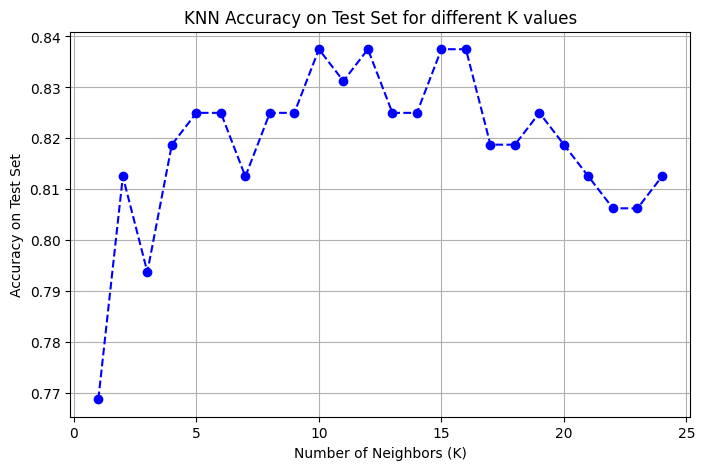

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 25)
acc_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_pca, y_train)
    pred = knn.predict(X_test_pca)
    acc_list.append(accuracy_score(y_test, pred))

best_k = k_values[acc_list.index(max(acc_list))]
best_acc = max(acc_list)

print("Best K:", best_k)
print(f"Best Accuracy on Test Set: {best_acc:.4f}")
plt.figure(figsize=(8, 5))
plt.plot(k_values, acc_list, marker='o', linestyle='--', color='blue')
plt.title("KNN Accuracy on Test Set for different K values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy on Test Set")
plt.grid(True)
plt.show()

Accuracy : 0.825
Precision: 0.5625
Recall   : 0.5625
F1 Score : 0.5625
Sensitivity (TPR): 0.5625


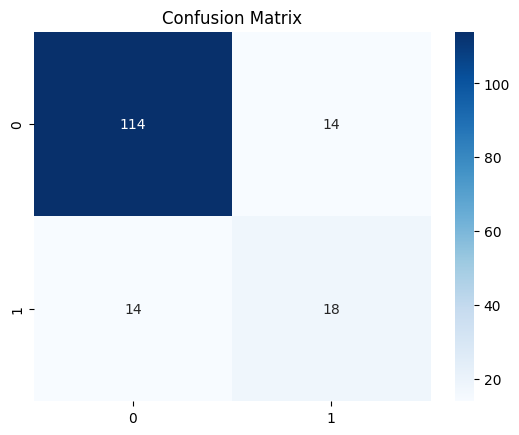

In [ ]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Sensitivity is equivalent to Recall
sensitivity = recall_score(y_test, y_pred)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("Sensitivity (TPR):", sensitivity)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

ROC AUC Score: 0.846435546875


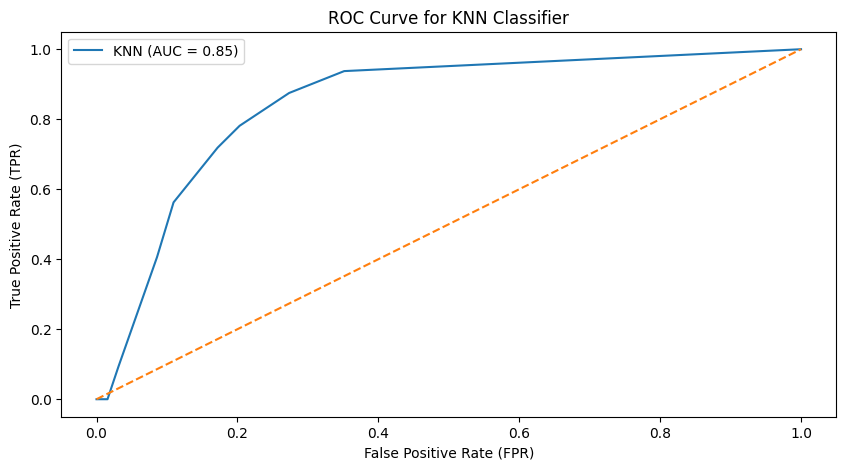

In [ ]:
# Predicted probability for Positive class
y_prob = knn.predict_proba(X_test_pca)[:, 1]

# Calculate FPR, TPR, Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", auc)

# ROC Curve Plot
plt.figure(figsize=(10,5))
plt.plot(fpr, tpr, label="KNN (AUC = {:.2f})".format(auc))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for KNN Classifier")
plt.legend()
plt.show()

In [ ]:
!zip -r my_project.zip .

  adding: .config/ (stored 0%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/gce (stored 0%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/.last_update_check.json (deflated 23%)
  adding: .config/config_sentinel (stored 0%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2025.11.20/ (stored 0%)
  adding: .config/logs/2025.11.20/14.30.45.937471.log (deflated 56%)
  adding: .config/logs/2025.11.20/14.30.36.623222.log (deflated 58%)
  adding: .config/logs/2025.11.20/14.30.35.382199.log (deflated 87%)
  adding: .config/logs/2025.11.20/14.30.04.285207.log (deflated 93%)
  adding: .config/logs/2025.11.20/14.30.27.010422.log (deflated 58%)
  adding: .config/logs/2025.11.20/14.30.45.231815.log (deflated 57%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/active_config (stored 0%)
  adding: .config/hi